# U-Net Exploration & Transition to Diffusion Models
In this notebook we will:
1. Build and train a basic U-Net for image segmentation on synthetic data.
2. Visualize intermediate outputs and predictions.
3. Discuss how the U-Net architecture is adapted in diffusion models (e.g., Stable Diffusion) for image generation.




---

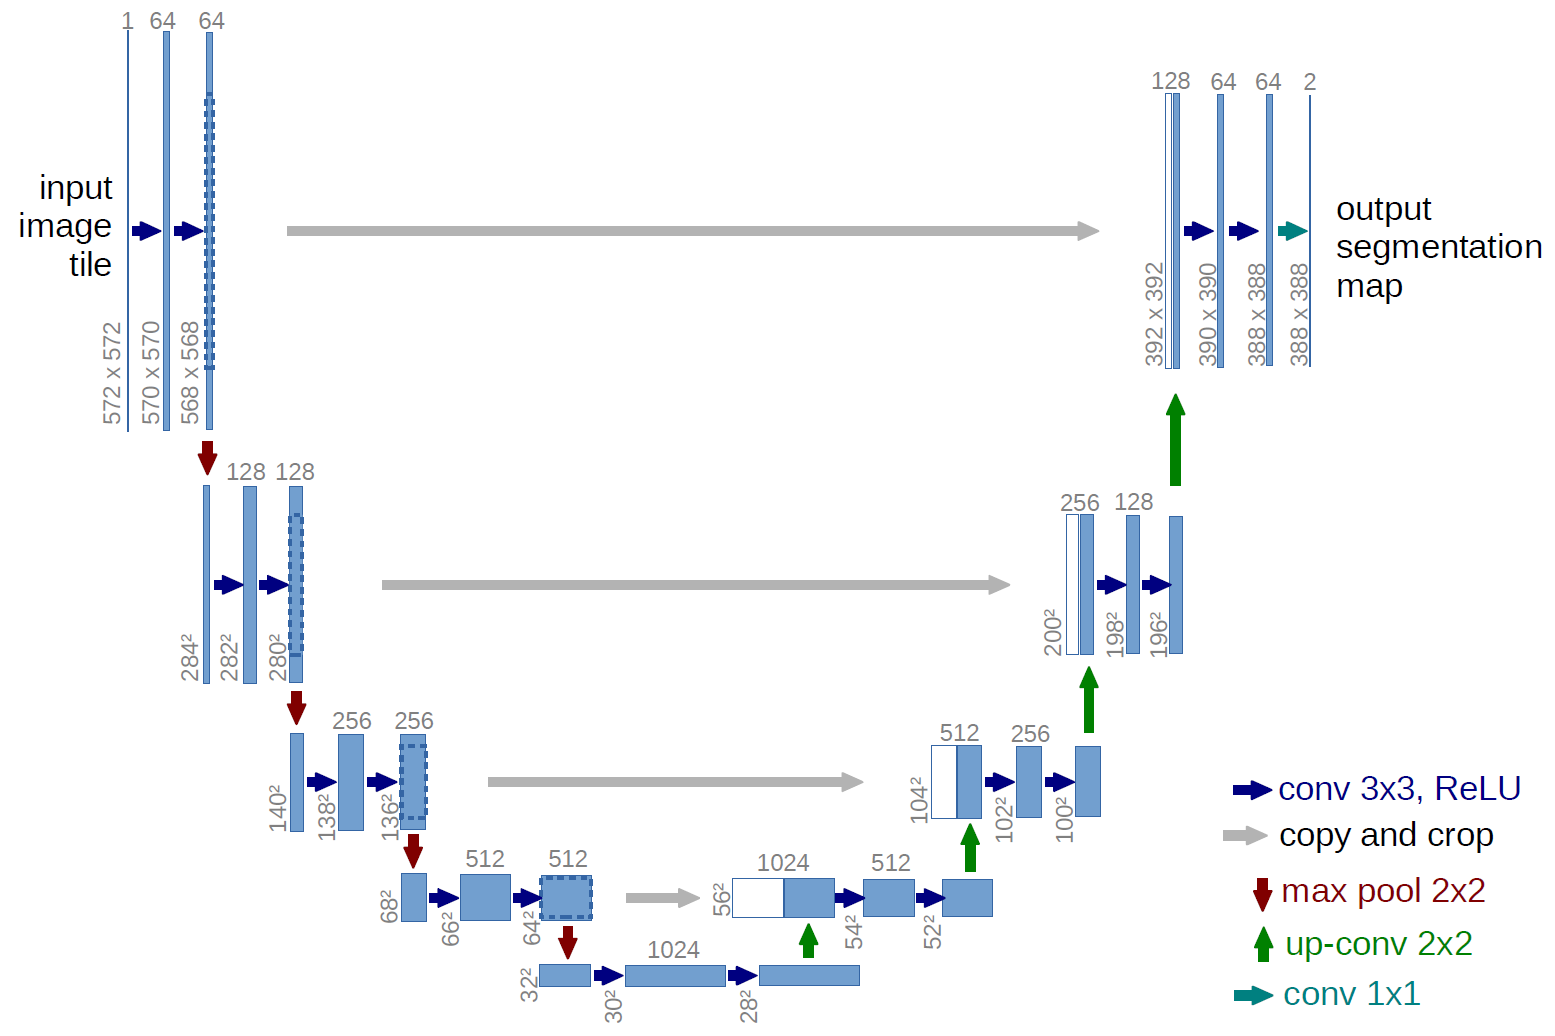

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, init_features=32):
        super(UNet, self).__init__()
        features = init_features
        # Encoder: Contracting Path
        self.encoder1 = UNet._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder2 = UNet._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder3 = UNet._block(features * 2, features * 4, name="enc3")
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder4 = UNet._block(features * 4, features * 8, name="enc4")
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = UNet._block(features * 8, features * 16, name="bottleneck")

        # Decoder: Expanding Path
        self.upconv4 = nn.ConvTranspose2d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = UNet._block((features * 8) * 2, features * 8, name="dec4")
        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = UNet._block((features * 4) * 2, features * 4, name="dec3")
        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = UNet._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = UNet._block(features * 2, features, name="dec1")

        # Final 1x1 convolution to get desired output channels
        self.conv = nn.Conv2d(features, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))
        bottleneck = self.bottleneck(self.pool4(enc4))

        # Decoder with skip connections
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        # Final output
        return torch.sigmoid(self.conv(dec1))

    @staticmethod
    def _block(in_channels, features, name):
        # A helper function that returns a block of two convolutional layers with ReLU activations and BatchNorm
        return nn.Sequential(
            nn.Conv2d(in_channels, features, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(inplace=True),
            nn.Conv2d(features, features, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(inplace=True),
            # 'name' is just a label for this block (for clarity)
        )

# Example: print total number of trainable parameters
if __name__ == "__main__":
    model = UNet(in_channels=3, out_channels=1, init_features=32)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters in U-Net: {total_params}")


Total trainable parameters in U-Net: 7763041


**Create a Synthetic Segmentation Dataset**

This cell creates a simple dataset where each sample consists of an image with a randomly drawn black rectangle (simulating an object) and a corresponding binary mask. The mask has white pixels (value 255) where the rectangle is drawn and black (value 0) elsewhere.

Explanation:

**Image Creation**:
We create a white image and draw a random black rectangle on it.

**Mask Creation**:
A grayscale image is created where the drawn rectangle is white (255) and the background is black (0).

**Transform**:
The ToTensor() transform converts images from PIL format to PyTorch tensors scaled to [0, 1].

In [3]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import torchvision.transforms as transforms

class SyntheticSegmentationDataset(Dataset):
    def __init__(self, num_samples=100, image_size=(128, 128)):
        """
        Args:
            num_samples (int): Number of synthetic samples to generate.
            image_size (tuple): Size of each image (width, height).
        """
        self.num_samples = num_samples
        self.image_size = image_size
        self.transform = transforms.ToTensor()  # Converts PIL image to tensor [C x H x W] in range [0, 1]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Create a blank white RGB image
        image = Image.new("RGB", self.image_size, "white")
        draw = ImageDraw.Draw(image)

        # Draw a random black rectangle to simulate an object
        x1 = np.random.randint(10, self.image_size[0] // 2)
        y1 = np.random.randint(10, self.image_size[1] // 2)
        x2 = np.random.randint(self.image_size[0] // 2, self.image_size[0] - 10)
        y2 = np.random.randint(self.image_size[1] // 2, self.image_size[1] - 10)
        draw.rectangle([x1, y1, x2, y2], fill="black")

        # Create a binary mask: white where the rectangle is, black elsewhere.
        mask = Image.new("L", self.image_size, 0)  # "L" mode for grayscale (0-255)
        draw_mask = ImageDraw.Draw(mask)
        draw_mask.rectangle([x1, y1, x2, y2], fill=255)

        # Convert images to tensors
        image_tensor = self.transform(image)  # [3, H, W]
        mask_tensor = self.transform(mask)      # [1, H, W] with values in [0, 1]
        return image_tensor, mask_tensor

# Create dataset and dataloader
dataset = SyntheticSegmentationDataset(num_samples=100)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Synthetic dataset created. Number of samples:", len(dataset))


Synthetic dataset created. Number of samples: 100


**Training Loop for U-Net**
This cell sets up the training loop for the U-Net model. We use Binary Cross-Entropy (BCE) loss since our segmentation mask is binary (0 for background, 1 for the object). The optimizer used is Adam.

**Explanation**:

**Training Mode**
model.train() sets the model to training mode to ensure layers like dropout and batchnorm work correctly.

**Loss Calculation** :
We compute the BCE loss between the predicted mask and the ground truth.

**Backward Pass**:
We perform backpropagation with loss.backward() and update weights with optimizer.step().

**Loss Reporting**:
We accumulate the loss over batches and print the average loss per epoch.



In [4]:
import torch.optim as optim

# Instantiate U-Net, loss criterion, and optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_channels=3, out_channels=1, init_features=32).to(device)
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for segmentation
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


Epoch 1/5, Loss: 0.4386
Epoch 2/5, Loss: 0.3179
Epoch 3/5, Loss: 0.2454
Epoch 4/5, Loss: 0.1968
Epoch 5/5, Loss: 0.1542


**Visualizing Results**
After training, it's important to visually inspect the model's predictions. This cell retrieves a batch from the dataloader, runs the model in evaluation mode, and then plots the input images, the ground truth masks, and the predicted segmentation masks.

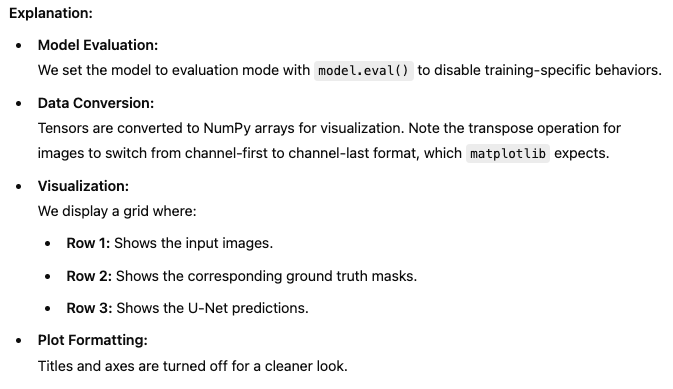

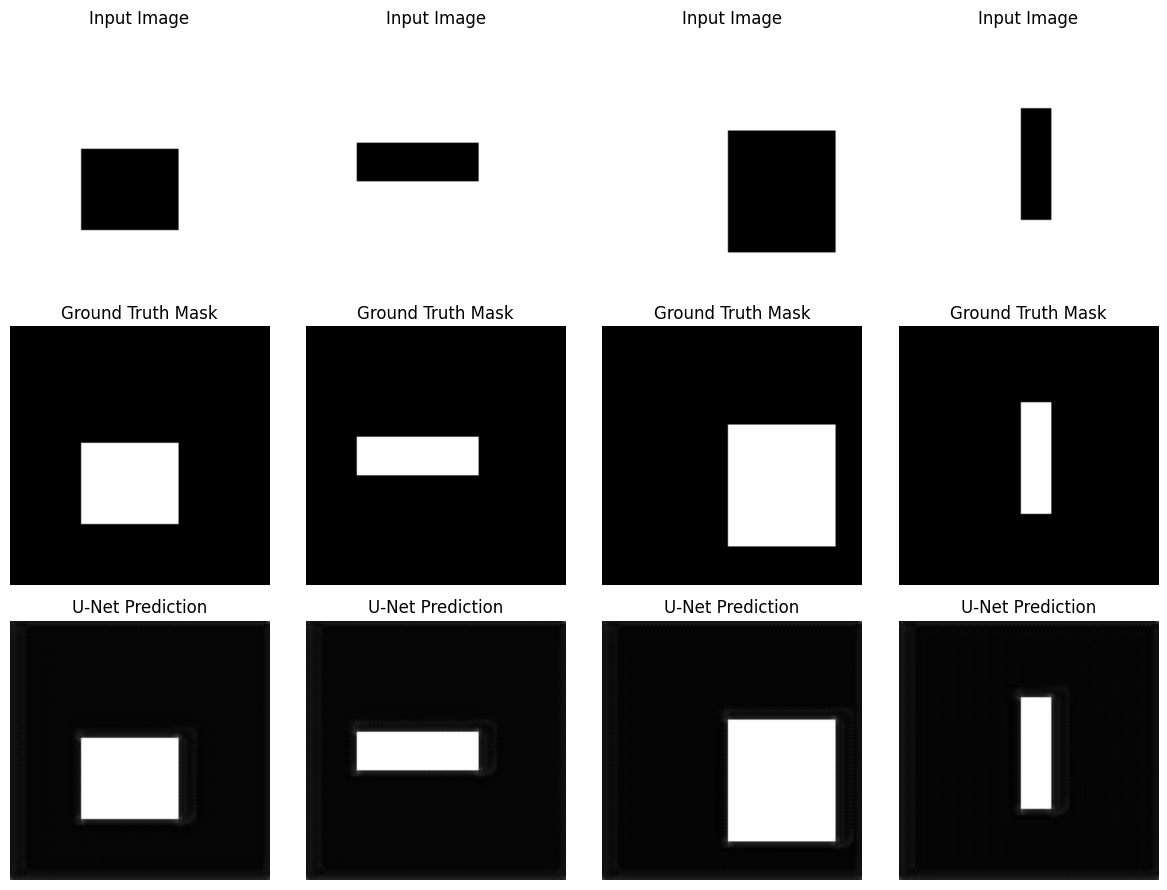

In [5]:
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

# Get one batch of samples from the dataloader
images, masks = next(iter(dataloader))
images = images.to(device)
with torch.no_grad():
    outputs = model(images)

# Convert tensors to numpy arrays for display
# Transpose the image tensor dimensions from [batch, channels, height, width] to [batch, height, width, channels]
images_np = images.cpu().numpy().transpose(0, 2, 3, 1)
# Squeeze channel dimension for masks and outputs (they are [batch, 1, height, width])
masks_np = masks.cpu().numpy().squeeze(1)
outputs_np = outputs.cpu().numpy().squeeze(1)

# Plotting the results: input image, ground truth mask, and predicted mask
fig, axs = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    axs[0, i].imshow(images_np[i])
    axs[0, i].set_title("Input Image")
    axs[0, i].axis("off")

    axs[1, i].imshow(masks_np[i], cmap="gray")
    axs[1, i].set_title("Ground Truth Mask")
    axs[1, i].axis("off")

    axs[2, i].imshow(outputs_np[i], cmap="gray")
    axs[2, i].set_title("U-Net Prediction")
    axs[2, i].axis("off")
plt.tight_layout()
plt.show()


# Transition: U-Net in Diffusion Models

We've seen how U-Net works effectively for image segmentation due to its encoder–decoder structure and skip connections. In modern generative models—like Stable Diffusion—the U-Net architecture is **adapted** as the denoising backbone. Key differences include:

- **Additional Inputs:** Time-step embeddings are added to condition the denoising process.
- **Cross-Attention Layers:** Integrate text embeddings (from models like CLIP) to guide image generation.
- **Latent Space Operation:** Diffusion is performed in a compressed latent space (using a VAE encoder/decoder), which is more efficient.

These adaptations allow diffusion models to generate high-quality, text-guided images by progressively refining noisy latent representations.

*Next Steps: Explore how to modify this U-Net for diffusion tasks or run image-to-image experiments with a diffusion pipeline!*


## **TO DO.......**